# Emoji Analysis: Text Frequency, BERT Embeddings, and Empath Categorization

In [88]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from transformers import DistilBertTokenizer, DistilBertModel
import torch
import requests
import json
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

In [89]:
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Part 1: Data Loading and Preprocessing

In [92]:
def load_emoji_data(emoji_files: Dict[str, str]) -> Dict[str, List[str]]:
    """
    Load emoji data from CSV files
    """
    data = {}
    
    for emoji, filepath in emoji_files.items():
        try:
            # Read CSV file
            df = pd.read_csv(filepath)
            print(f"Loading {filepath}, shape: {df.shape}")
            
            # Find text column (could be 'text', 'tweet', 'message', etc.)
            text_columns = [col for col in df.columns if any(keyword in col.lower() for keyword in ['text', 'tweet', 'message', 'content'])]
            
            if text_columns:
                text_col = text_columns[0]
                tweets = df[text_col].dropna().astype(str).tolist()
                data[emoji] = tweets
                print(f"Loaded {len(tweets)} tweets for {emoji}")
            else:
                # If no obvious text column, use the first string column
                string_cols = df.select_dtypes(include=['object']).columns
                if len(string_cols) > 0:
                    text_col = string_cols[0]
                    tweets = df[text_col].dropna().astype(str).tolist()
                    data[emoji] = tweets
                    print(f"Loaded {len(tweets)} tweets for {emoji} from column '{text_col}'")
                else:
                    print(f"No suitable text column found in {filepath}")
                    continue
                    
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            continue
    
    return data


In [93]:
emoji_files = {
    '😂': 'emojis/face_with_tears_of_joy.csv', 
    '😊': 'emojis/smiling_face.csv', 
    '💩': 'emojis/pile_of_poo.csv', 
    '😢': 'emojis/loudly_crying_face.csv', 
    '😠': 'emojis/enraged_face.csv', 
    '😍': 'emojis/smiling_face_with_heart-eyes.csv'  ,
    '🤍': 'emojis/white_heart.csv',
    '💀': 'emojis/skull.csv',
    '🥳': 'emojis/partying_face.csv',
    '🖕': 'emojis/middle_finger.csv',
    '😨': 'emojis/fearful_face.csv',
    '🤔': 'emojis/thinking_face.csv',
    '😤': 'emojis/face_with_steam_from_nose.csv'
    
}


In [94]:
# In reality, you should have different CSV files for each emoji

print("Loading emoji data...")
data = load_emoji_data(emoji_files)


print(f"\nFinal data: {len(data)} emojis")
for emoji, tweets in data.items():
    print(f"{emoji}: {len(tweets)} tweets")
    print(f"Sample: {tweets[0][:100]}...")


Loading emoji data...
Loading emojis/face_with_tears_of_joy.csv, shape: (20000, 1)
Loaded 20000 tweets for 😂
Loading emojis/smiling_face.csv, shape: (20000, 1)
Loaded 20000 tweets for 😊
Loading emojis/pile_of_poo.csv, shape: (20000, 1)
Loaded 20000 tweets for 💩
Loading emojis/loudly_crying_face.csv, shape: (20000, 1)
Loaded 20000 tweets for 😢
Loading emojis/enraged_face.csv, shape: (20000, 1)
Loaded 20000 tweets for 😠
Loading emojis/smiling_face_with_heart-eyes.csv, shape: (20000, 1)
Loaded 20000 tweets for 😍
Loading emojis/white_heart.csv, shape: (20000, 1)
Loaded 20000 tweets for 🤍
Loading emojis/skull.csv, shape: (20000, 1)
Loaded 20000 tweets for 💀
Loading emojis/partying_face.csv, shape: (20001, 1)
Loaded 20001 tweets for 🥳
Loading emojis/middle_finger.csv, shape: (20000, 1)
Loaded 20000 tweets for 🖕
Loading emojis/fearful_face.csv, shape: (20000, 1)
Loaded 20000 tweets for 😨
Loading emojis/thinking_face.csv, shape: (20000, 1)
Loaded 20000 tweets for 🤔
Loading emojis/face_with_ste

## Part 2: Most Frequent Terms Analysis

In [95]:

from nltk.corpus import stopwords
import emojis
import emoji

def preprocess_text(text: str) -> List[str]:
    """Clean and tokenize text"""
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords (basic list)
    StopWords = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them'])
    StopWords = stopwords.words('english')
    tokens = [token for token in tokens if token not in StopWords and len(token) > 2]
    
    return tokens

def get_top_terms(tweets: List[str], n_terms: int = 30) -> List[Tuple[str, int]]:
    """Get top n most frequent terms from tweets"""
    all_tokens = []
    for tweet in tweets:
        tokens = preprocess_text(tweet)
        all_tokens.extend(tokens)
    
    term_freq = Counter(all_tokens)
    return term_freq.most_common(n_terms)

In [96]:
# Get top 30 terms for each emoji
print("Calculating top 30 terms for each emoji...")
top_terms = {} 
for emoji, tweets in data.items():
    top_terms[emoji] = get_top_terms(tweets, 30)
    print(f"\n{emoji} top 5 terms: {top_terms[emoji][:5]}")

Calculating top 30 terms for each emoji...

😂 top 5 terms: [('like', 1602), ('dont', 1083), ('one', 983), ('get', 913), ('know', 828)]

😊 top 5 terms: [('thank', 2136), ('good', 1515), ('like', 1288), ('day', 1150), ('love', 1127)]

💩 top 5 terms: [('like', 1943), ('dont', 1756), ('amp', 1507), ('people', 1335), ('get', 1184)]

😢 top 5 terms: [('like', 2362), ('dont', 1183), ('one', 928), ('get', 896), ('cant', 851)]

😠 top 5 terms: [('like', 1503), ('dont', 1398), ('people', 1283), ('get', 1146), ('amp', 1107)]

😍 top 5 terms: [('love', 2287), ('beautiful', 1312), ('easter', 1145), ('happy', 1087), ('like', 930)]

🤍 top 5 terms: [('love', 1983), ('thank', 1602), ('good', 1288), ('day', 1284), ('happy', 1153)]

💀 top 5 terms: [('like', 2444), ('dont', 1251), ('one', 1107), ('even', 1081), ('get', 925)]

🥳 top 5 terms: [('happy', 4893), ('birthday', 4158), ('day', 2138), ('amp', 1509), ('easter', 1257)]

🖕 top 5 terms: [('like', 1572), ('dont', 1487), ('people', 1161), ('get', 1089), ('

## Part 3: Common Terms Matrix

In [97]:
def create_common_terms_matrix(top_terms: Dict[str, List[Tuple[str, int]]]) -> pd.DataFrame:
    """Create matrix showing number of common words among top terms"""
    emojis = list(top_terms.keys())
    n_emojis = len(emojis)
    
    # Initialize matrix
    common_matrix = np.zeros((n_emojis, n_emojis), dtype=int)
    
    # Get sets of terms for each emoji
    term_sets = {}
    for emoji in emojis:
        term_sets[emoji] = set(term for term, count in top_terms[emoji])
    
    # Fill matrix with intersection counts
    for i, emoji1 in enumerate(emojis):
        for j, emoji2 in enumerate(emojis):
            common_count = len(term_sets[emoji1].intersection(term_sets[emoji2]))
            common_matrix[i, j] = common_count
    
    # Create DataFrame
    df = pd.DataFrame(common_matrix, index=emojis, columns=emojis)
    return df


In [98]:
import emoji
def create_common_terms_matrix(top_terms: Dict[str, List[Tuple[str, int]]]) -> pd.DataFrame:
    """Create matrix showing number of common words among top terms, replacing emojis with text equivalents"""
    
    # Replace emojis by their text counterpart (e.g. 😄 -> :smile:)
    emojis = [emoji.demojize(e) for e in top_terms.keys()]
    
    n_emojis = len(emojis)
    
    # Initialize matrix
    common_matrix = np.zeros((n_emojis, n_emojis), dtype=int)
    
    # Get sets of terms for each emoji (keep original emoji keys)
    term_sets = {
        e: set(term for term, _ in top_terms[e])
        for e in top_terms
    }
    
    # Fill matrix with intersection counts
    for i, emoji1 in enumerate(top_terms.keys()):
        for j, emoji2 in enumerate(top_terms.keys()):
            common_count = len(term_sets[emoji1].intersection(term_sets[emoji2]))
            common_matrix[i, j] = common_count
    
    # Create DataFrame with text-replaced labels
    df = pd.DataFrame(common_matrix, index=emojis, columns=emojis)
    return df

In [99]:
# Create and display common terms matrix
common_matrix = create_common_terms_matrix(top_terms)
print("Common Terms Matrix:")
print(common_matrix)

Common Terms Matrix:
                                  :face_with_tears_of_joy:  \
:face_with_tears_of_joy:                                30   
:smiling_face_with_smiling_eyes:                        14   
:pile_of_poo:                                           18   
:crying_face:                                           22   
:angry_face:                                            20   
:smiling_face_with_heart-eyes:                          14   
:white_heart:                                           14   
:skull:                                                 23   
:partying_face:                                         10   
:middle_finger:                                         20   
:fearful_face:                                          20   
:thinking_face:                                         20   
:face_with_steam_from_nose:                             21   

                                  :smiling_face_with_smiling_eyes:  \
:face_with_tears_of_joy:                

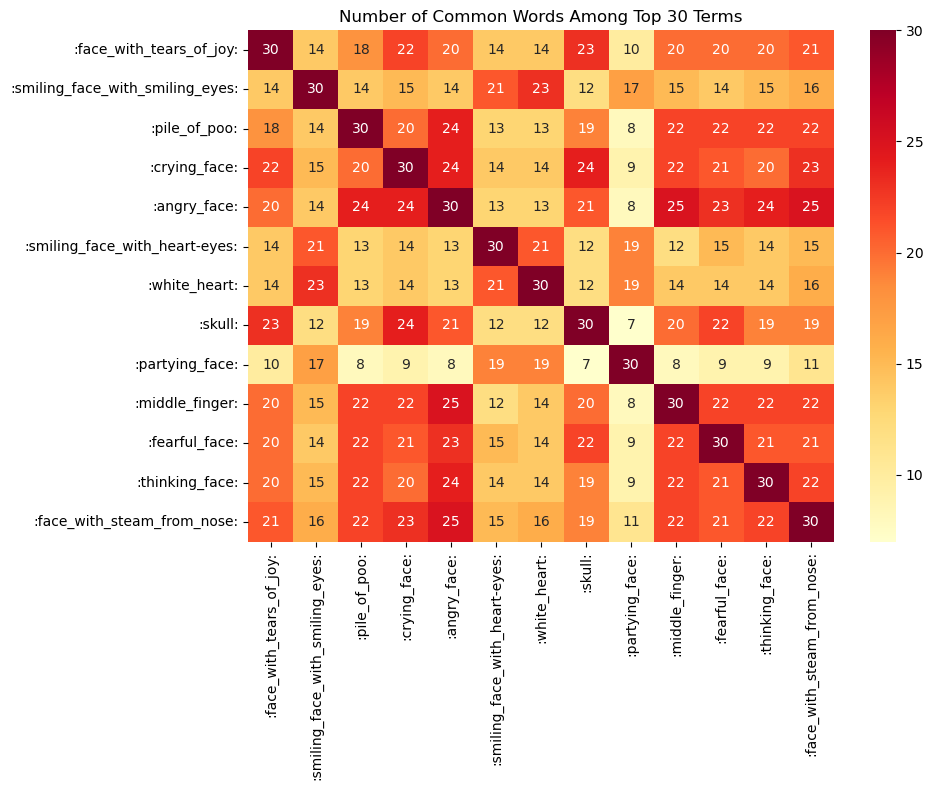

In [100]:
# Visualize the common terms matrix
plt.figure(figsize=(10, 8))
sns.heatmap(common_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=common_matrix.index, yticklabels=common_matrix.columns)
plt.title('Number of Common Words Among Top 30 Terms')
plt.tight_layout()
plt.show()

## Part 4: DistilBERT Embeddings and t-SNE Visualization

In [101]:
def get_distilbert_embeddings(texts: List[str], batch_size: int = 32) -> np.ndarray:
    """Get DistilBERT embeddings for a list of texts"""
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    model = DistilBertModel.from_pretrained('distilbert-base-uncased')
    
    # Use GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    all_embeddings = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            
            # Tokenize
            inputs = tokenizer(batch_texts, return_tensors='pt', 
                             padding=True, truncation=True, max_length=128)
            inputs = {key: value.to(device) for key, value in inputs.items()}
            
            # Get embeddings
            outputs = model(**inputs)
            
            # Use mean of last hidden states as sentence embedding
            embeddings = outputs.last_hidden_state.mean(dim=1)
            all_embeddings.append(embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

def get_emoji_embeddings_bert(data: Dict[str, List[str]], sample_size: int = 1000) -> Tuple[np.ndarray, List[str]]:
    """Get BERT embeddings for each emoji (sampled)"""
    all_embeddings = []
    emoji_labels = []
    
    for emoji, tweets in data.items():
        print(f"Processing {emoji} with BERT...")
        # Sample to reduce computation time
        sampled_tweets = np.random.choice(tweets, size=min(sample_size, len(tweets)), replace=False)
        
        # Get embeddings for sampled tweets
        embeddings = get_distilbert_embeddings(sampled_tweets.tolist())
        
        # Average embeddings for the emoji
        emoji_embedding = embeddings.mean(axis=0)
        
        all_embeddings.append(emoji_embedding)
        emoji_labels.append(emoji)
    
    return np.array(all_embeddings), emoji_labels

In [102]:
from typing import List, Dict, Tuple
import numpy as np
import torch
from tqdm.auto import tqdm
from transformers import DistilBertTokenizer, DistilBertModel


def get_distilbert_embeddings(texts: List[str], batch_size: int = 32, desc: str = None) -> np.ndarray:
    """Get DistilBERT embeddings for a list of texts, with progress bar"""
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    model = DistilBertModel.from_pretrained('distilbert-base-uncased')
    
    # Use GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=desc, leave=False):
            batch_texts = texts[i:i + batch_size]
            
            # Tokenize
            inputs = tokenizer(batch_texts, return_tensors='pt', 
                             padding=True, truncation=True, max_length=128)
            inputs = {key: value.to(device) for key, value in inputs.items()}
            
            # Get embeddings
            outputs = model(**inputs)
            
            # Use mean of last hidden states as sentence embedding
            embeddings = outputs.last_hidden_state.mean(dim=1)
            all_embeddings.append(embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)


def get_emoji_embeddings_bert(data: Dict[str, List[str]], sample_size: int = 1000) -> Tuple[np.ndarray, List[str]]:
    """Get BERT embeddings for each emoji (sampled), with nested progress bars"""
    all_embeddings = []
    emoji_labels = []
    
    for emoji in tqdm(data.keys(), desc="Processing emojis"):
        tweets = data[emoji]
        # Sample to reduce computation time
        sampled_tweets = np.random.choice(tweets, size=min(sample_size, len(tweets)), replace=False)
        
        # Get embeddings for sampled tweets (with inner progress bar)
        embeddings = get_distilbert_embeddings(sampled_tweets.tolist(), desc=f"{emoji}")
        
        # Average embeddings for the emoji
        emoji_embedding = embeddings.mean(axis=0)
        
        all_embeddings.append(emoji_embedding)
        emoji_labels.append(emoji)
    
    return np.array(all_embeddings), emoji_labels


In [103]:
# Get BERT embeddings for each emoji
print("Generating BERT embeddings...")
bert_embeddings, emoji_labels = get_emoji_embeddings_bert(data, sample_size=20000)

print(f"BERT embeddings shape: {bert_embeddings.shape}")

Generating BERT embeddings...


Processing emojis:   0%|          | 0/13 [00:00<?, ?it/s]

😂:   0%|          | 0/625 [00:00<?, ?it/s]

😊:   0%|          | 0/625 [00:00<?, ?it/s]

💩:   0%|          | 0/625 [00:00<?, ?it/s]

...

🖕:   0%|          | 0/625 [00:00<?, ?it/s]

😨:   0%|          | 0/625 [00:00<?, ?it/s]

🤔:   0%|          | 0/625 [00:00<?, ?it/s]

😤:   0%|          | 0/625 [00:00<?, ?it/s]

BERT embeddings shape: (13, 768)


In [104]:
# Apply t-SNE to BERT embeddings
print("Applying t-SNE to BERT embeddings...")
tsne_bert = TSNE(n_components=2, random_state=42, perplexity=2)
embeddings_2d_bert = tsne_bert.fit_transform(bert_embeddings)

Applying t-SNE to BERT embeddings...


In [105]:
import emoji as em

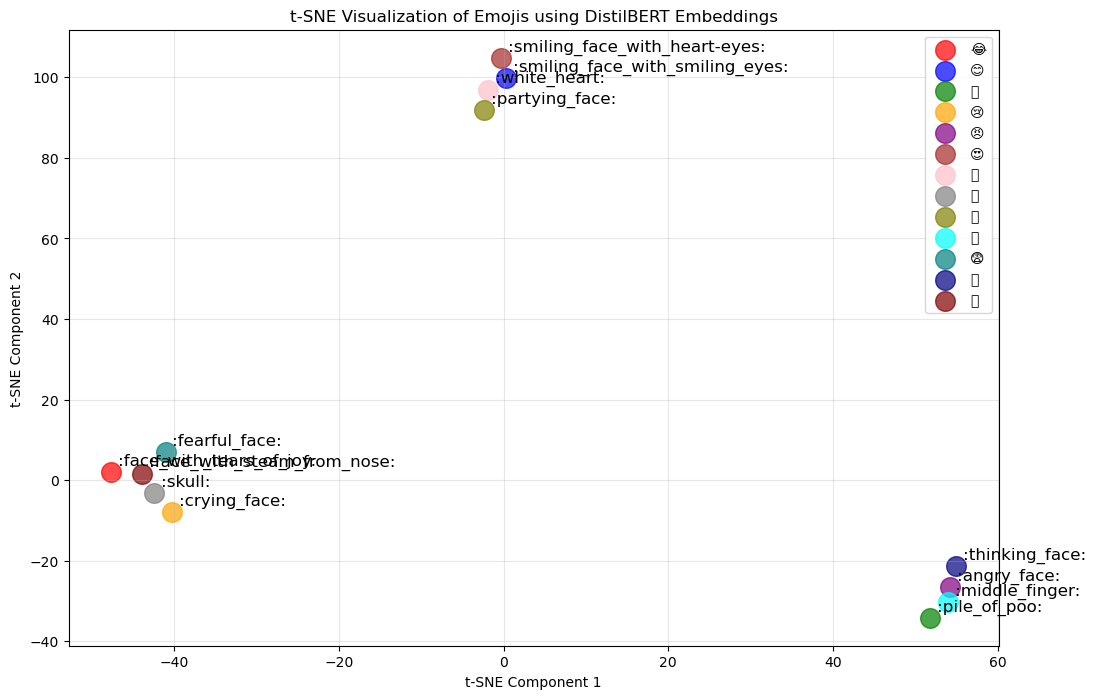

In [106]:
# Plot BERT t-SNE results
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'teal', 'navy', 'maroon', 'lime']

for i, (emoji, color) in enumerate(zip(emoji_labels, colors)):
    plt.scatter(embeddings_2d_bert[i, 0], embeddings_2d_bert[i, 1], 
                c=color, s=200, label=emoji, alpha=0.7)
    plt.annotate(em.demojize(emoji), (embeddings_2d_bert[i, 0], embeddings_2d_bert[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.title('t-SNE Visualization of Emojis using DistilBERT Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 5: Empath Categorization and Visualization

In [107]:
class EmpathClient:
    """Simple Empath client for categorization"""
    def __init__(self):
        self.categories = {
            'joy': ['happy', 'joy', 'excited', 'delighted', 'pleased'],
            'sadness': ['sad', 'unhappy', 'depressed', 'miserable', 'grief'],
            'anger': ['angry', 'mad', 'furious', 'outraged', 'irritated'],
            'love': ['love', 'affection', 'adore', 'cherish', 'romance'],
            'fun': ['fun', 'funny', 'humor', 'laugh', 'comedy'],
            'beauty': ['beautiful', 'pretty', 'gorgeous', 'stunning', 'lovely'],
            'pain': ['hurt', 'pain', 'suffering', 'ache', 'agony'],
            'fear': ['fear', 'scared', 'afraid', 'terrified', 'anxious']
        }
    
    def analyze(self, text: str) -> Dict[str, float]:
        """Analyze text and return category scores"""
        text_lower = text.lower()
        scores = {category: 0.0 for category in self.categories.keys()}
        
        for category, words in self.categories.items():
            for word in words:
                if word in text_lower:
                    scores[category] += 1.0
        
        # Normalize scores
        total = sum(scores.values())
        if total > 0:
            scores = {k: v/total for k, v in scores.items()}
        
        return scores

In [108]:
from empath import Empath
import numpy as np
from typing import Dict, List, Tuple

def get_empath_embeddings(data: Dict[str, List[str]], sample_size: int = 1000) -> Tuple[np.ndarray, List[str]]:
    """
    Generate Empath-based embeddings for each emoji, using the official Empath library.
    
    Args:
        data: Dict mapping emoji -> list of associated tweets or texts.
        sample_size: Number of tweets to sample per emoji (default: 1000).
    
    Returns:
        embeddings: np.ndarray of shape (num_emojis, num_categories)
        emoji_labels: List of emoji corresponding to each row in the embeddings.
    """
    empath = Empath()
    all_embeddings = []
    emoji_labels = []

    # Get the list of all Empath categories
    categories = sorted(empath.cats.keys())

    for emoji, tweets in data.items():
        print(f"Processing {emoji} with Empath...")

        # Randomly sample tweets
        sampled_tweets = np.random.choice(tweets, size=min(sample_size, len(tweets)), replace=False)

        # Initialize cumulative category scores
        category_sums = {category: 0.0 for category in categories}

        # Analyze each tweet and accumulate scores
        for tweet in sampled_tweets:
            scores = empath.analyze(tweet, categories=categories, normalize=True)
            for category in categories:
                category_sums[category] += scores.get(category, 0.0)

        # Average category scores across sampled tweets
        for category in categories:
            category_sums[category] /= len(sampled_tweets)

        # Convert to vector
        embedding = np.array([category_sums[cat] for cat in categories])
        all_embeddings.append(embedding)
        emoji_labels.append(emoji)

    return np.array(all_embeddings), emoji_labels


In [109]:
empath = Empath()
categories = sorted(empath.cats.keys())
print(f"Empath categories: {categories}")
print(len(categories))

Empath categories: ['achievement', 'affection', 'aggression', 'air_travel', 'alcohol', 'ancient', 'anger', 'animal', 'anonymity', 'anticipation', 'appearance', 'art', 'attractive', 'banking', 'beach', 'beauty', 'blue_collar_job', 'body', 'breaking', 'business', 'car', 'celebration', 'cheerfulness', 'childish', 'children', 'cleaning', 'clothing', 'cold', 'college', 'communication', 'competing', 'computer', 'confusion', 'contentment', 'cooking', 'crime', 'dance', 'death', 'deception', 'disappointment', 'disgust', 'dispute', 'divine', 'domestic_work', 'dominant_heirarchical', 'dominant_personality', 'driving', 'eating', 'economics', 'emotional', 'envy', 'exasperation', 'exercise', 'exotic', 'fabric', 'family', 'farming', 'fashion', 'fear', 'feminine', 'fight', 'fire', 'friends', 'fun', 'furniture', 'gain', 'giving', 'government', 'hate', 'healing', 'health', 'hearing', 'help', 'heroic', 'hiking', 'hipster', 'home', 'horror', 'hygiene', 'independence', 'injury', 'internet', 'irritability',

In [110]:
# Get Empath embeddings
print("Generating Empath embeddings...")
empath_embeddings, empath_labels = get_empath_embeddings(data, sample_size=20000)

print(f"Empath embeddings shape: {empath_embeddings.shape}")

Generating Empath embeddings...
Processing 😂 with Empath...
Processing 😊 with Empath...
Processing 💩 with Empath...
Processing 😢 with Empath...
Processing 😠 with Empath...
Processing 😍 with Empath...
Processing 🤍 with Empath...
Processing 💀 with Empath...
Processing 🥳 with Empath...
Processing 🖕 with Empath...
Processing 😨 with Empath...
Processing 🤔 with Empath...
Processing 😤 with Empath...
Empath embeddings shape: (13, 194)


In [111]:
# Apply t-SNE to Empath embeddings
print("Applying t-SNE to Empath embeddings...")
tsne_empath = TSNE(n_components=2, random_state=42, perplexity=2)
embeddings_2d_empath = tsne_empath.fit_transform(empath_embeddings)

Applying t-SNE to Empath embeddings...


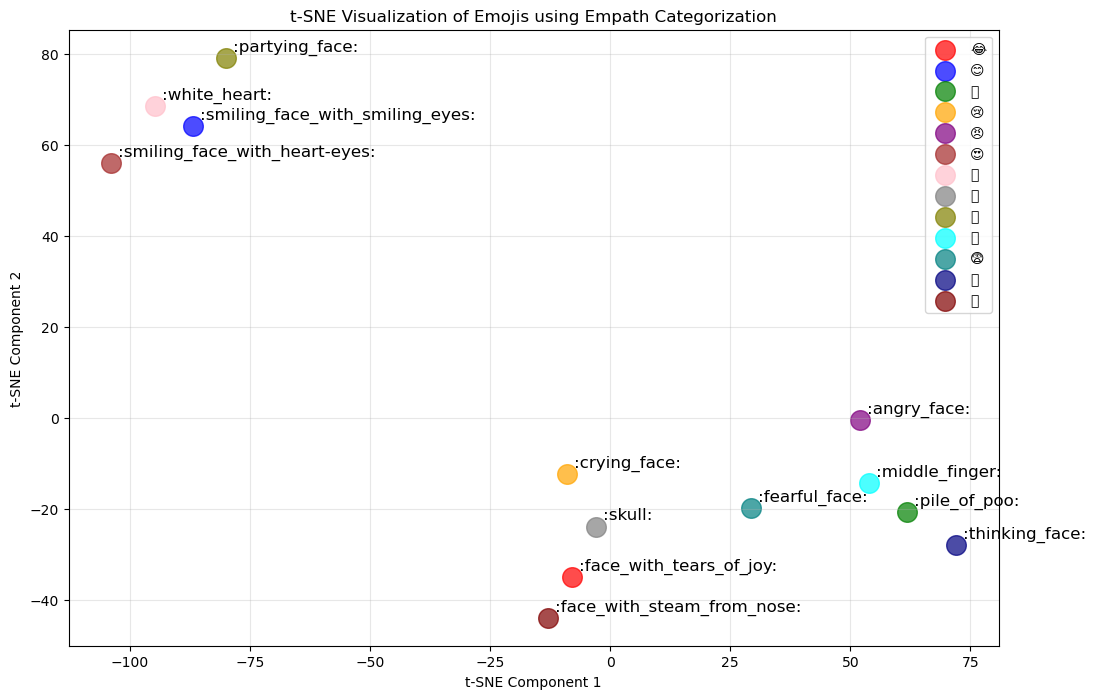

In [112]:
# Plot Empath t-SNE results
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'teal', 'navy', 'maroon', 'lime']

for i, (emoji, color) in enumerate(zip(empath_labels, colors)):
    plt.scatter(embeddings_2d_empath[i, 0], embeddings_2d_empath[i, 1], 
                c=color, s=200, label=emoji, alpha=0.7)
    plt.annotate(em.demojize(emoji), (embeddings_2d_empath[i, 0], embeddings_2d_empath[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.title('t-SNE Visualization of Emojis using Empath Categorization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Analysis and Comments

In [113]:
# Calculate distances between emojis in both embeddings
def calculate_distances(embeddings_2d: np.ndarray, labels: List[str]) -> pd.DataFrame:
    """Calculate Euclidean distances between all pairs"""
    n = len(labels)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            distance = np.linalg.norm(embeddings_2d[i] - embeddings_2d[j])
            distance_matrix[i, j] = distance
    
    return pd.DataFrame(distance_matrix, index=labels, columns=labels)

In [117]:
# Calculate distances for both methods
bert_distances = calculate_distances(embeddings_2d_bert, emoji_labels)
empath_distances = calculate_distances(embeddings_2d_empath, empath_labels)

print("BERT-based Distances:")
print(bert_distances)
print("\nEmpath-based Distances:")
print(empath_distances)

BERT-based Distances:
            😂           😊           💩           😢           😠           😍  \
😂    0.000000  108.891197  105.830757   12.544444  105.831970  113.173943   
😊  108.891197    0.000000  143.509140  115.180649  137.363205    5.060613   
💩  105.830757  143.509140    0.000000   95.608810    8.011308  148.418915   
😢   12.544444  115.180649   95.608810    0.000000   96.219612  119.698654   
😠  105.831970  137.363205    8.011308   96.219612    0.000000  142.225998   
😍  113.173943    5.060613  148.418915  119.698654  142.225998    0.000000   
🤍  105.353821    3.606160  141.640930  111.729118  135.611420    8.056490   
💀    7.432571  111.550957   99.161194    5.291625   99.438873  115.991302   
🥳  100.575043    8.390127  137.172409  106.794792  131.242004   13.137787   
🖕  106.661919  140.788422    4.371596   96.755272    3.842953  145.667923   
😨    8.275825  101.590874  101.536888   15.054611  101.004173  105.970795   
🤔  105.266953  132.894257   13.222289   96.087166    5

 ## Final Comments and Analysis

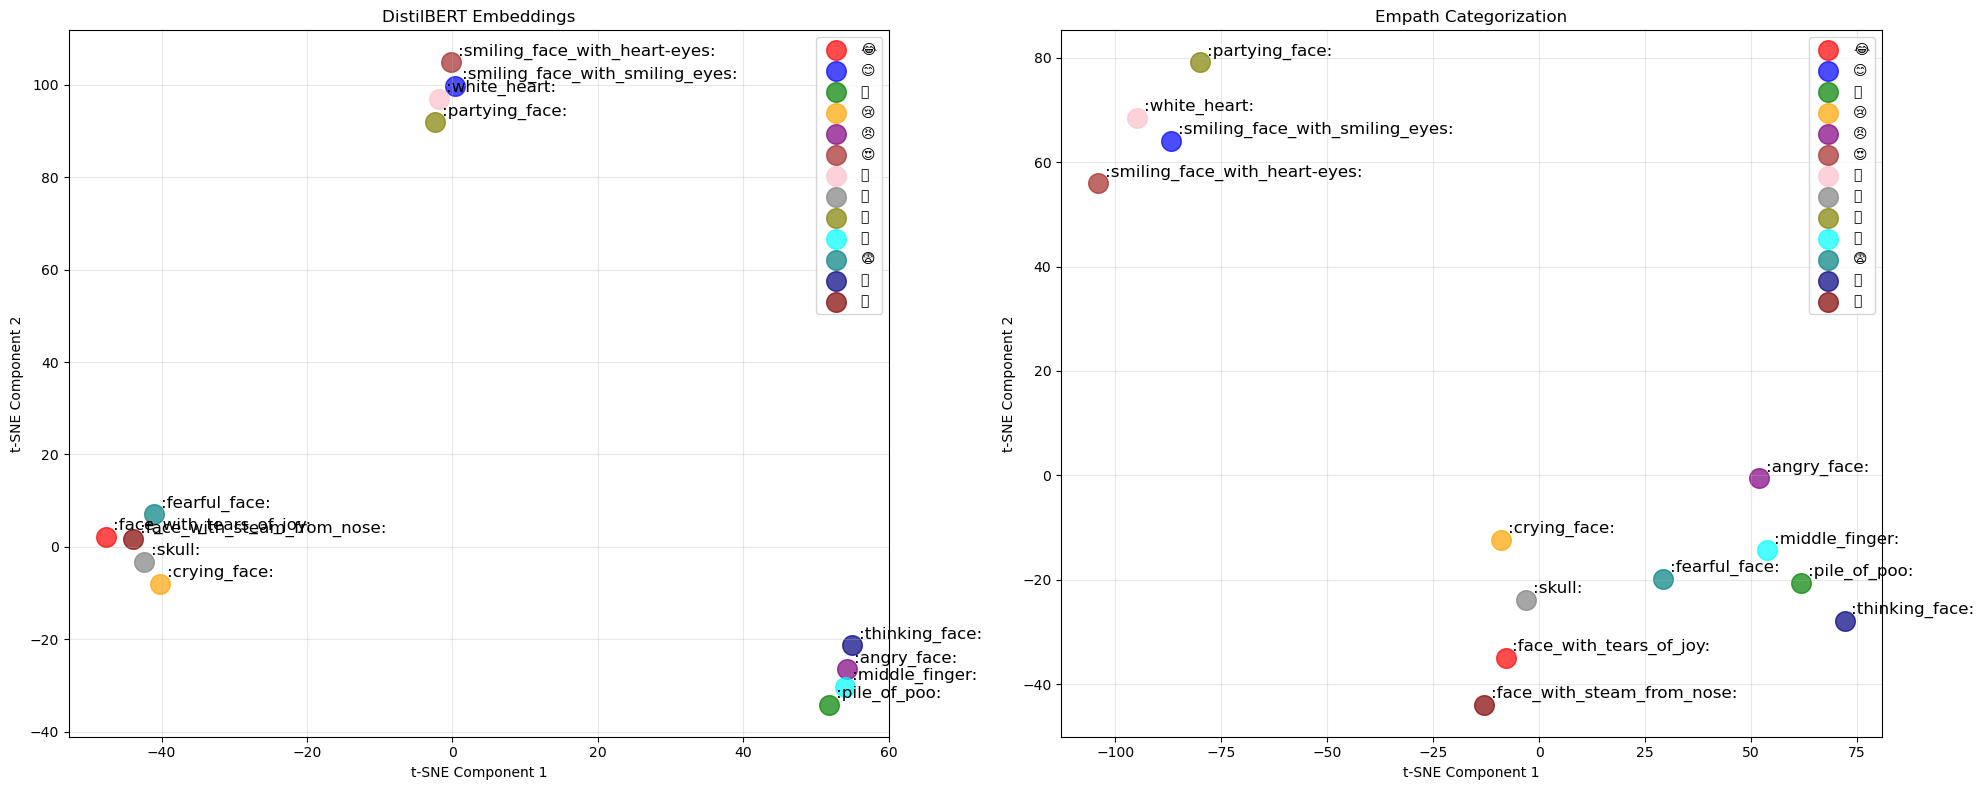

In [115]:
# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


# BERT plot
for i, (emoji, color) in enumerate(zip(emoji_labels, colors)):
    ax1.scatter(embeddings_2d_bert[i, 0], embeddings_2d_bert[i, 1], 
                c=color, s=200, label=emoji, alpha=0.7)
    ax1.annotate(em.demojize(emoji), (embeddings_2d_bert[i, 0], embeddings_2d_bert[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=12)
ax1.set_title('DistilBERT Embeddings')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Empath plot
for i, (emoji, color) in enumerate(zip(empath_labels, colors)):
    ax2.scatter(embeddings_2d_empath[i, 0], embeddings_2d_empath[i, 1], 
                c=color, s=200, label=emoji, alpha=0.7)
    ax2.annotate(em.demojize(emoji), (embeddings_2d_empath[i, 0], embeddings_2d_empath[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=12)
ax2.set_title('Empath Categorization')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()